<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predict employee salaries based on job characteristics, professional experience, and company attributes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('job_salary_prediction_dataset.csv')

In [ ]:
df.head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


In [ ]:
df.shape


(250000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


* The dataset include 6 categorical features and 4 numerical features.

In [ ]:
df.isna().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [ ]:
df.duplicated().sum()

np.int64(0)

**There is no duplicated raws and null features in dataset.**

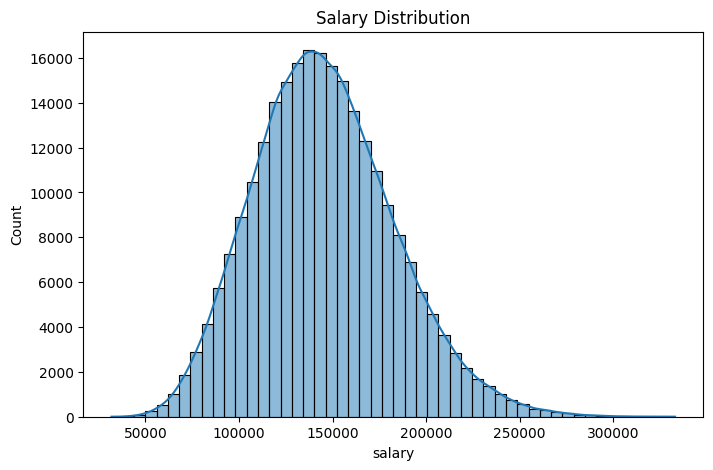

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary"], bins = 50, kde = True)
plt.title("Salary Distribution")
plt.show()

* Based on this Histogram Salary follows a slightly right-skewed distribution.

* Most salaries cluster in mid ranges.

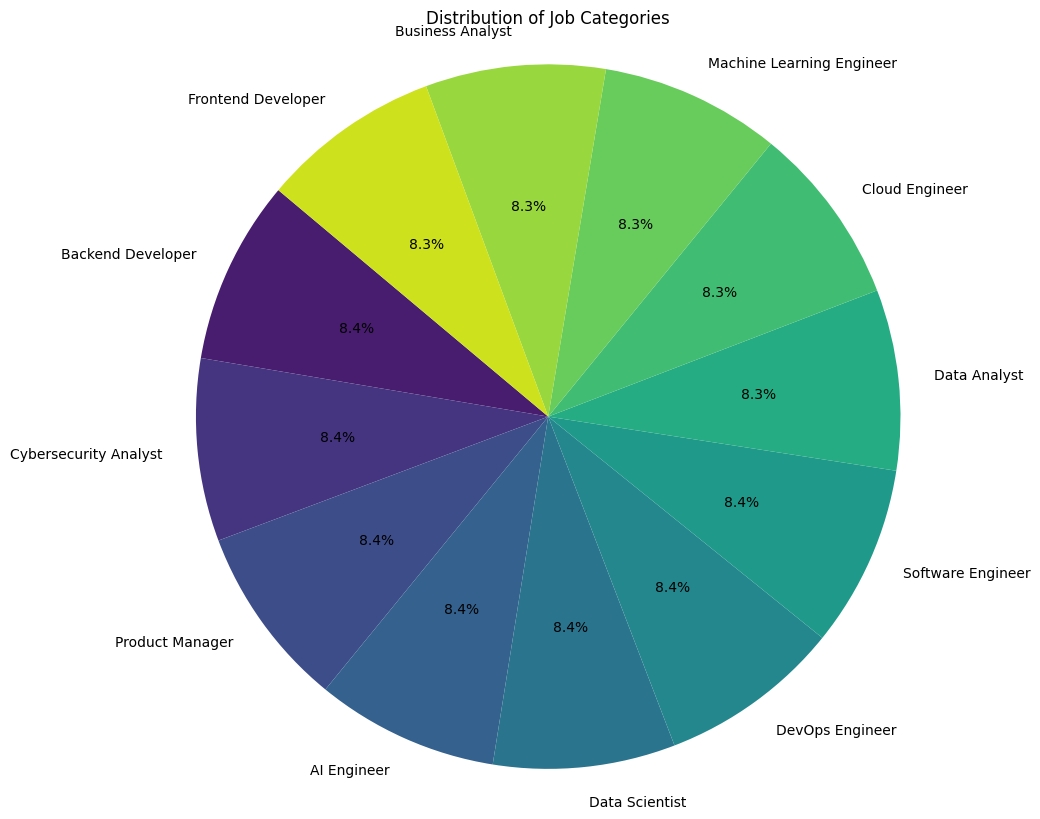

In [ ]:
# Visualize the distribution of jobs by category using a pie chart
job_counts = df['job_title'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(job_counts, labels=job_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(job_counts)))
plt.title('Distribution of Job Categories')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

**The pie chart shows that the dataset is extremely well-balanced, with each of the 12 job titles accounting for approximately 8.3% to 8.4% of the total entries.**

<Figure size 1400x800 with 0 Axes>

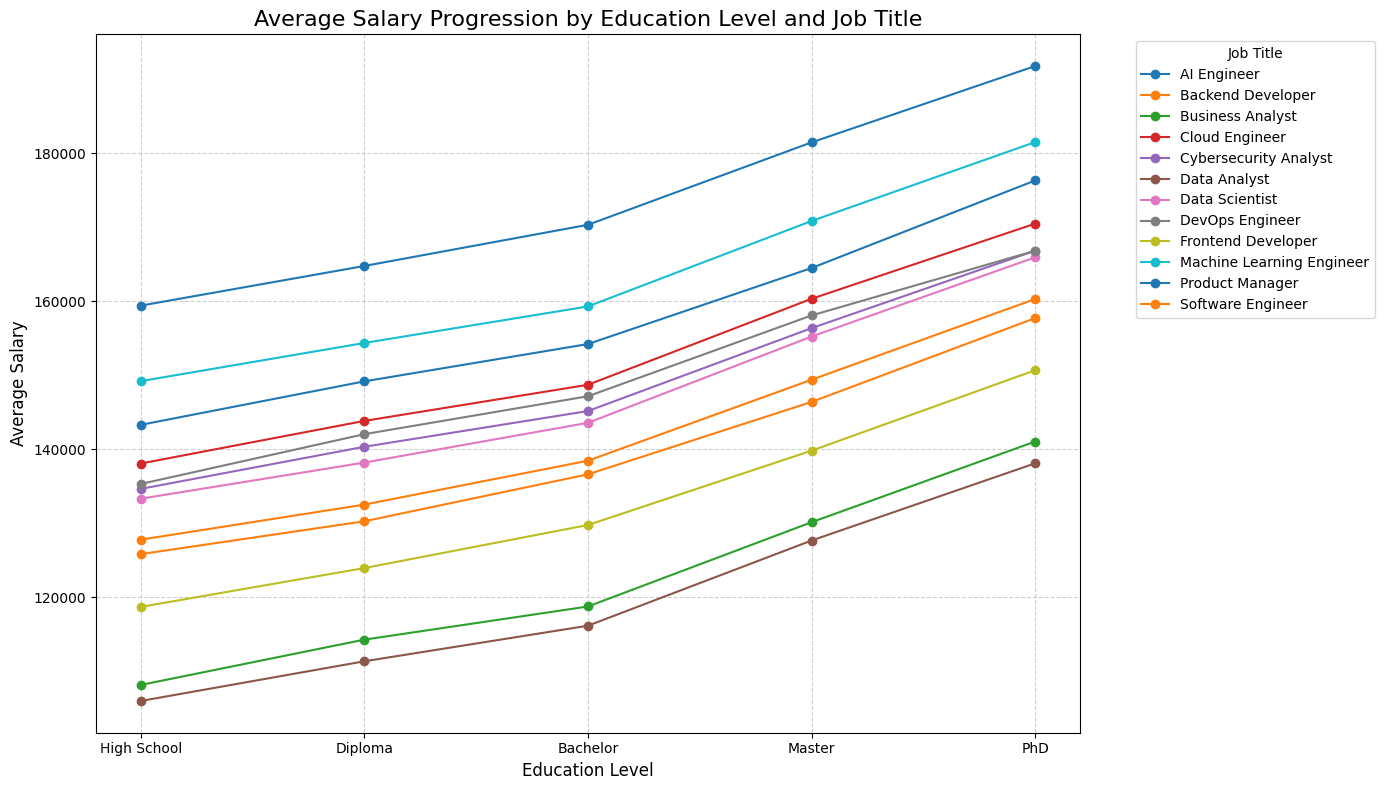

In [ ]:
import matplotlib.pyplot as plt

# Define the correct ordinal order for education levels
education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']

# Create a pivot table for the line chart
salary_line_pivot = df.pivot_table(index='education_level', columns='job_title', values='salary', aggfunc='mean')

# Reindex to ensure education levels are in logical order on the X-axis
salary_line_pivot = salary_line_pivot.reindex(education_order)

# Plotting the line chart
plt.figure(figsize=(14, 8))
salary_line_pivot.plot(kind='line', marker='o', figsize=(14, 8))

plt.title('Average Salary Progression by Education Level and Job Title', fontsize=16)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Average Salary', fontsize=12)
plt.xticks(range(len(education_order)), education_order)
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Based on Line chart**
* Consistent Growth: Every job title (represented by a unique line color) shows a positive slope, confirming that as education levels move from High School to PhD, the average salary increases steadily.
* Also seen that AI Engineer and Machine Learning Engineer has best Average Salary and Data analyst and Business Analyst has lower salary across all education level.

### Exploring Categorical Features

Now, let's visualize the relationship between categorical features and salary. We'll start with `job_title`.

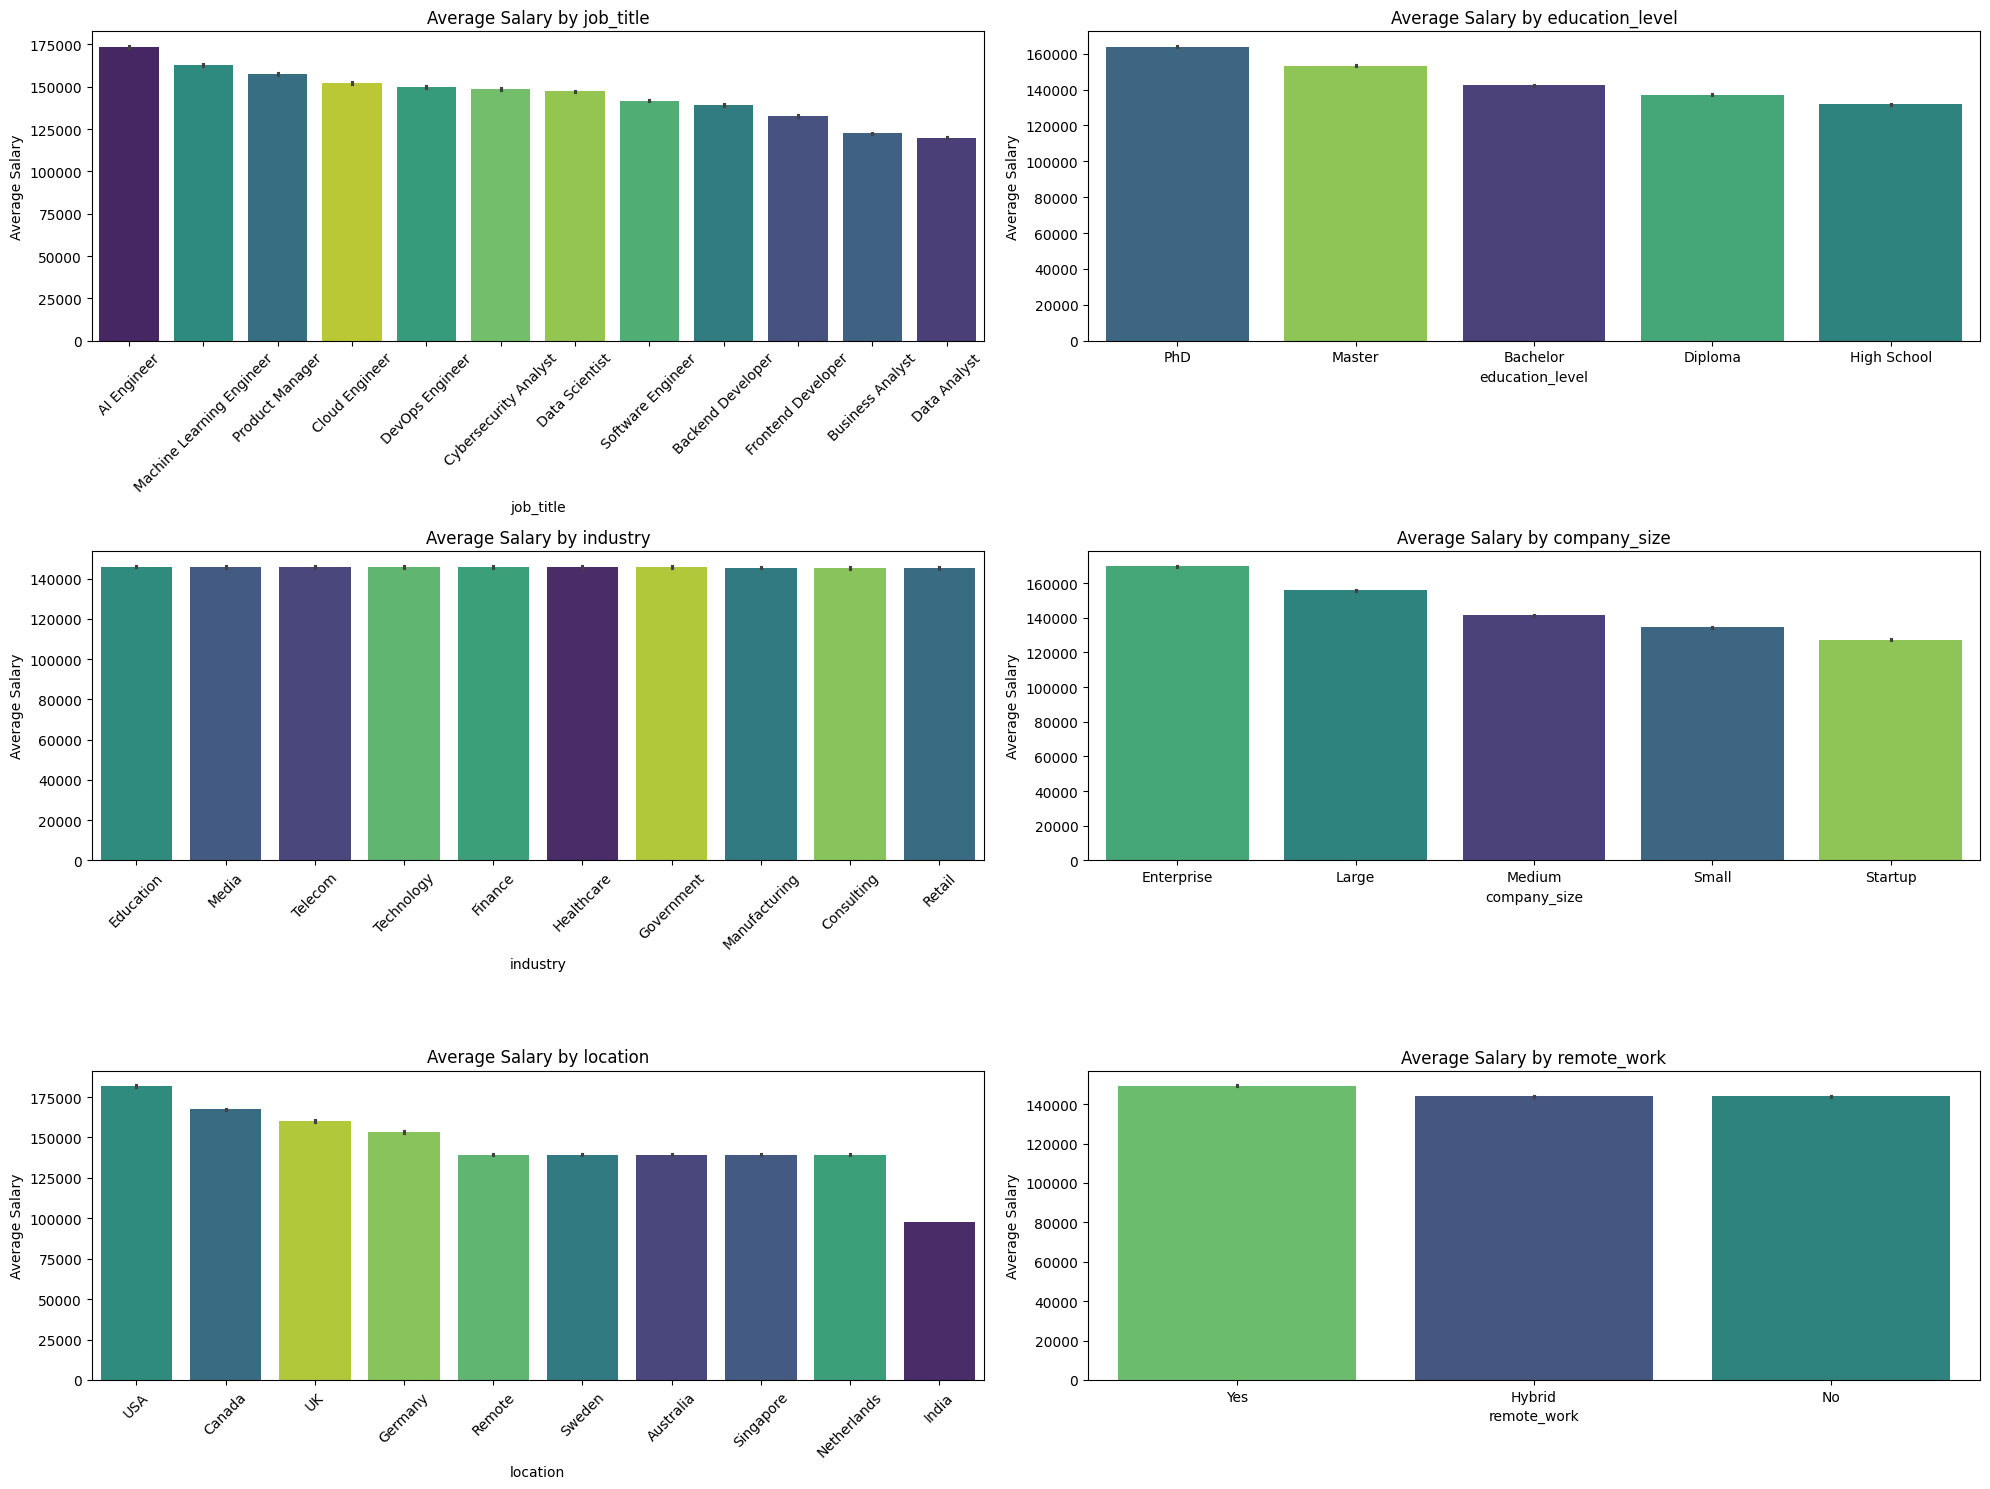

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifying categorical columns
categorical_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

# Setting up the figure for a grid of plots
plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    # Sorting by salary to make the relationship clearer
    avg_salary_order = df.groupby(col)['salary'].mean().sort_values(ascending=False).index
    sns.barplot(x=col, y='salary', data=df, order=avg_salary_order, palette='viridis', hue=col, legend=False)

    plt.title(f'Average Salary by {col}')
    plt.xticks(rotation=45 if col in ['job_title', 'industry', 'location'] else 0)
    plt.ylabel('Average Salary')

plt.tight_layout()
plt.show()

##Key observations from these plots include:

* Job Title & Location: Show significant variance in average pay.
* Education & Company Size: Exhibit a clear hierarchical trend where higher education and larger company sizes correlate with higher salaries.
* Remote Work: Shows very little variation in average salary across its categories, suggesting it might have less predictive power compared to the others.


### Boxplot Analysis for Outlier Detection

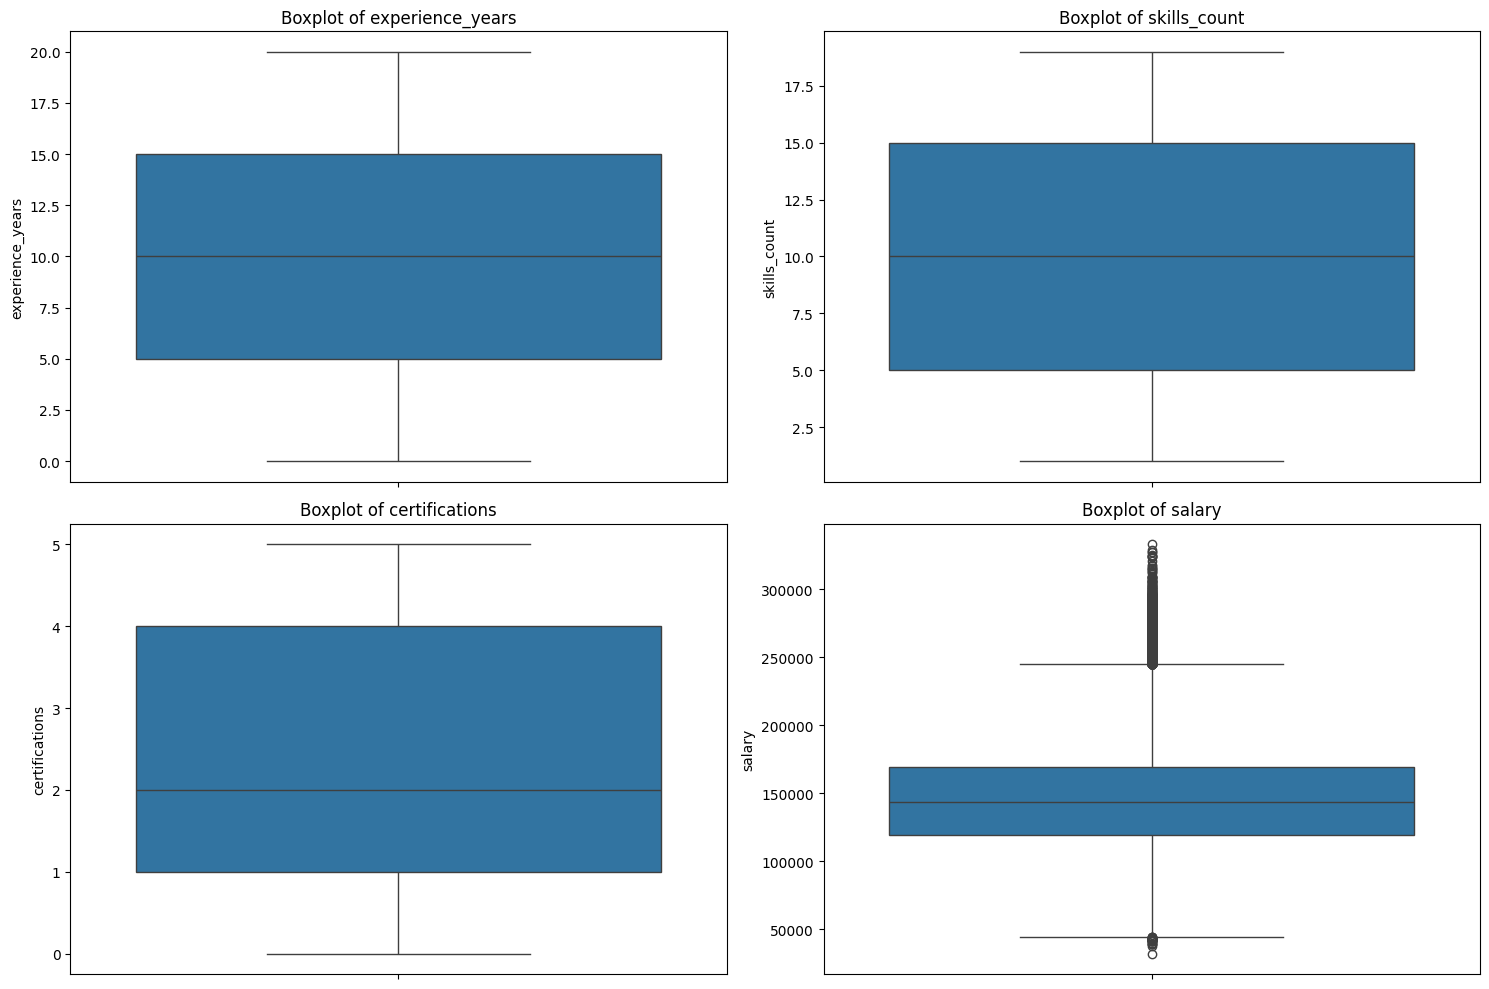

In [ ]:
numerical_cols = ['experience_years', 'skills_count', 'certifications', 'salary']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

**No outliers detected on numerical features. However, in target variable salary there is some extreme values that may have due to experience and job profiles so that won't be considered as an outliers.**

### Correlation heatmap across the numerical features

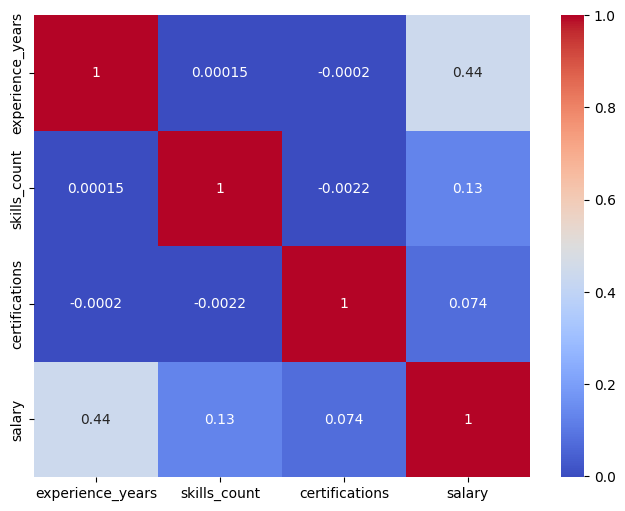

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize = (8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

**Based on this heatmap we can conclude that Experience feature is highly dominant(0.44) to salary. Also there is no multicolinearity in numerical features.**

### Salary vs Experience Analysis

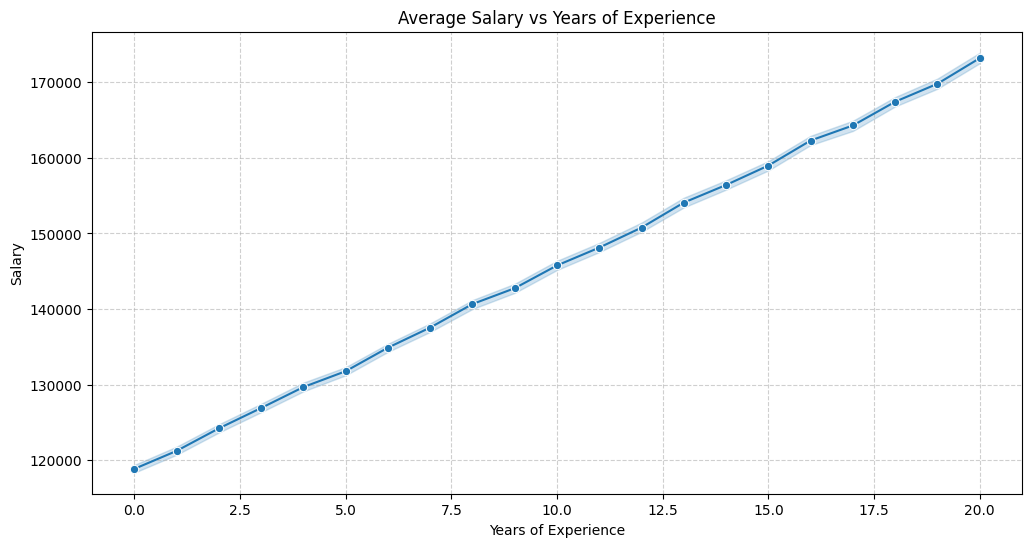

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='experience_years', y='salary', data=df, marker='o')
plt.title('Average Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

* The line plot clearly shows a strong positive linear relationship between years of experience and salary. As the number of years of experience increases, the average salary rises steadily, confirming that experience is a significant predictor of pay in this dataset.

In [ ]:
df.head()


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## Categorical Encoding
We will use **Ordinal Encoding** for hierarchical features like education_level and company_size and **One Hot Encoding** for the rest.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Reload the dataset to start fresh with raw categorical values
df = pd.read_csv('job_salary_prediction_dataset.csv').dropna()

# Define hierarchies for Ordinal Encoding
education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
size_order = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']

# Define columns for each encoder
nominal_cols = ['job_title', 'industry', 'location', 'remote_work']
ordinal_cols = ['education_level', 'company_size']

# Initialize ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[education_order, size_order]), ordinal_cols),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough' # Keep numerical columns (experience, skills, etc.)
)

# Apply transformations
# ColumnTransformer returns a numpy array, let's convert it back to a DataFrame for readability
encoded_data = preprocessor.fit_transform(df)

# Get the feature names after OneHot Encoding
new_cols = ordinal_cols + list(preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_cols)) + ['experience_years', 'skills_count', 'certifications', 'salary']

df_encoded = pd.DataFrame(encoded_data, columns=new_cols)

# Display the first few rows of the newly encoded data
display(df_encoded.head())

,education_level,company_size,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,job_title_Frontend Developer,...,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes,experience_years,skills_count,certifications,salary
0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,10.0,2.0,2.0,109413.0
1,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,5.0,17.0,0.0,93764.0
2,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,18.0,4.0,1.0,148123.0
3,4.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,19.0,13.0,0.0,189123.0
4,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,15.0,7.0,0.0,165069.0


### Correlation Heatmap (After One-Hot & Ordinal Encoding)
Now that we have expanded our features using One-Hot Encoding, we can visualize the full correlation matrix. This helps us see which specific dummy variables have the strongest impact on salary.

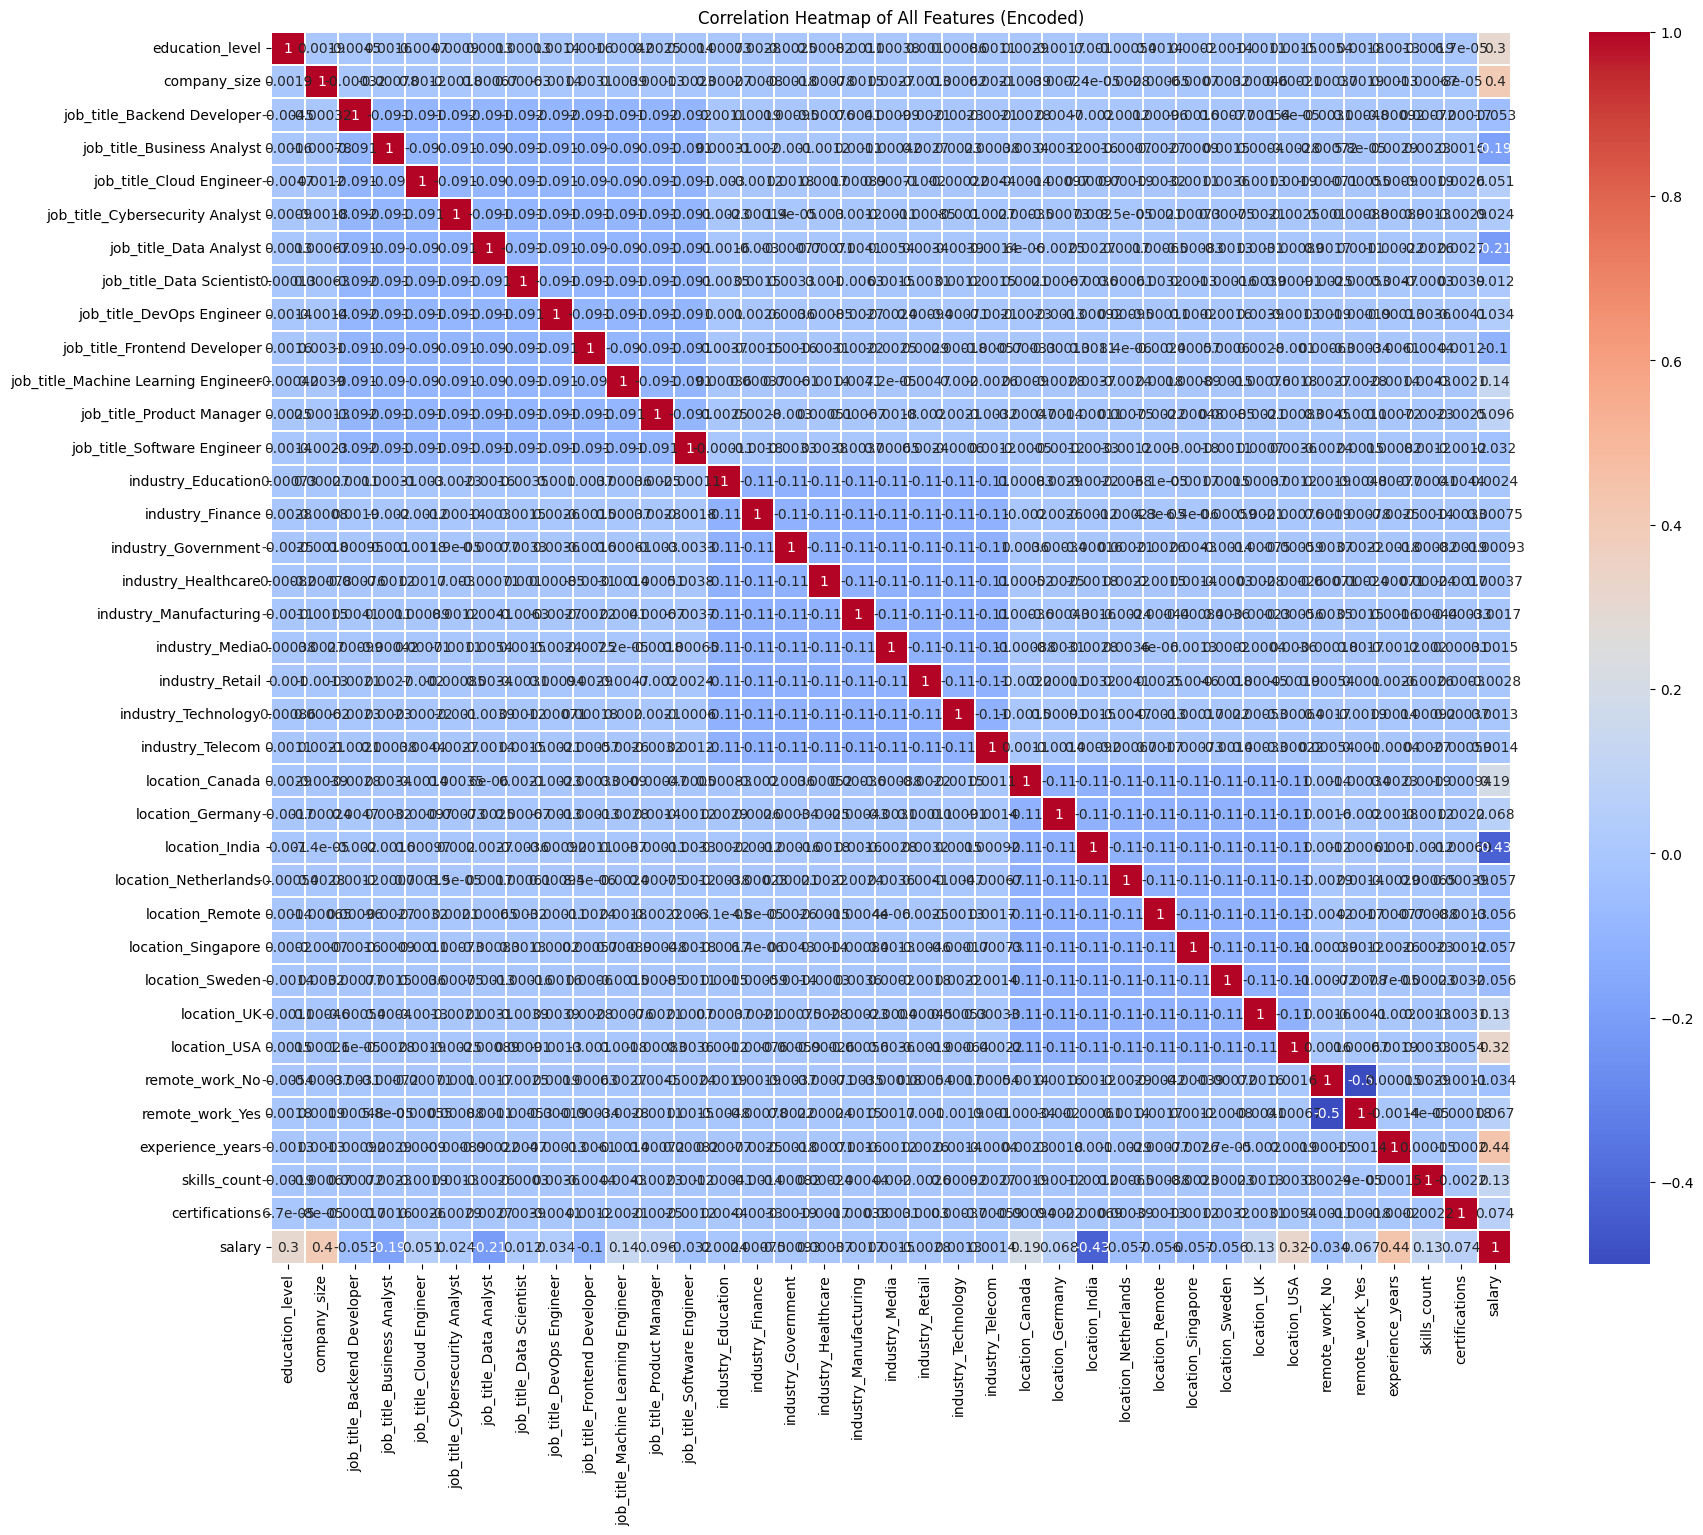

Top Correlations with Salary:


,salary
salary,1.000000
experience_years,0.437627
company_size,0.400253
location_USA,0.320280
education_level,0.304823
location_Canada,0.193832
job_title_Machine Learning Engineer,0.138904
location_UK,0.127725
skills_count,0.127300
job_title_Product Manager,0.096021


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix for the encoded dataframe
plt.figure(figsize=(20, 16))
full_corr = df_encoded.corr()

# Focusing on correlations with the target variable 'salary' for clarity in a dense matrix
sns.heatmap(full_corr, annot=True, cmap='coolwarm', linewidths=0.1)
plt.title('Correlation Heatmap of All Features (Encoded)')
plt.show()

# Display top 10 correlations with Salary
print("Top Correlations with Salary:")
display(full_corr['salary'].sort_values(ascending=False).head(10))

In [ ]:
# Display bottom (most negative) correlations
display(full_corr['salary'].sort_values().head(10))

,salary
location_India,-0.426965
job_title_Data Analyst,-0.207556
job_title_Business Analyst,-0.185820
job_title_Frontend Developer,-0.104746
location_Netherlands,-0.057059
location_Singapore,-0.056872
location_Sweden,-0.056061
location_Remote,-0.056001
job_title_Backend Developer,-0.052914
remote_work_No,-0.033843


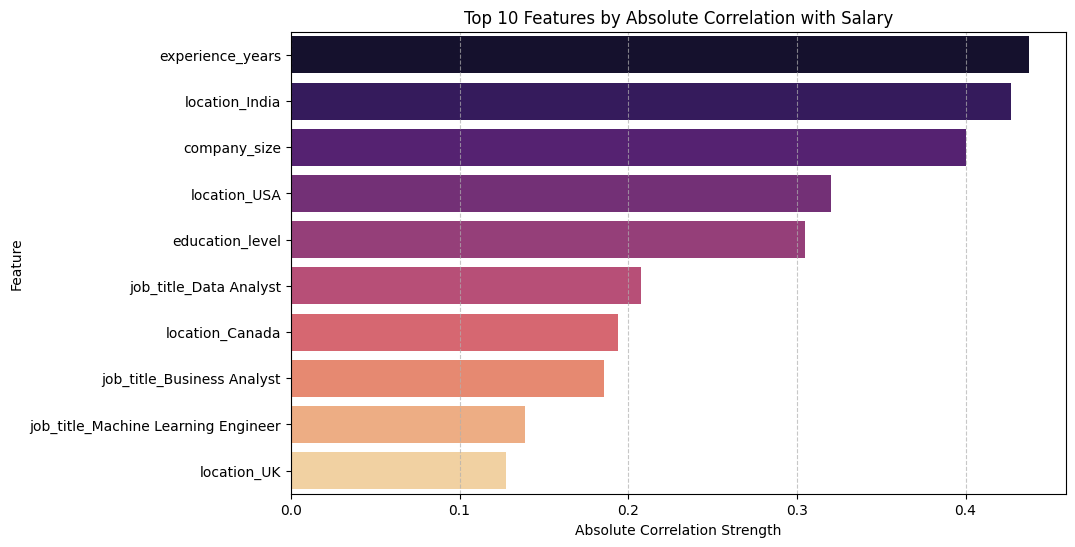

In [ ]:
# Get top 10 features by absolute correlation strength with salary
top_10_corr = df_encoded.corr()['salary'].abs().sort_values(ascending=False).iloc[1:11]

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_corr.values, y=top_10_corr.index, palette='magma', hue=top_10_corr.index, legend=False)
plt.title('Top 10 Features by Absolute Correlation with Salary')
plt.xlabel('Absolute Correlation Strength')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

* **Based on correlation heatmap we idetentified that Features like company_size, location_USA and education_level is positively correlated with salary.**
* **Also we found out that features like location_India and job_title_Data Analyst are negatively correlated with salary.**


### Feature Selection based on Correlation
To reduce dimensionality and focus on the most impactful features, we will drop columns that have a correlation with `salary` lower than a specific threshold (e.g., 0.05).

In [ ]:
threshold = 0.05

# Calculate correlation with the target variable
salary_corr = df_encoded.corr()['salary'].abs().sort_values()

# Identify features below the threshold
low_corr_features = salary_corr[salary_corr < threshold].index.tolist()

print(f"Features identified for removal (correlation < {threshold}):")
print(low_corr_features)



Features identified for removal (correlation < 0.05):
['industry_Healthcare', 'industry_Finance', 'industry_Government', 'industry_Technology', 'industry_Telecom', 'industry_Media', 'industry_Manufacturing', 'industry_Education', 'industry_Retail', 'job_title_Data Scientist', 'job_title_Cybersecurity Analyst', 'job_title_Software Engineer', 'remote_work_No', 'job_title_DevOps Engineer']


**Drop features that are less correlated to the salary and create dataset for train model.**

In [ ]:
# Drop the low-correlation features identified in the previous step
df_selected = df_encoded.drop(columns=low_corr_features)

print(f"Original feature count: {df_encoded.shape[1]}")
print(f"Reduced feature count: {df_selected.shape[1]}")
print("\nRemaining features:")
print(df_selected.columns.tolist())

# Quick check of the new dataframe
display(df_selected.head())

Original feature count: 37
Reduced feature count: 23

Remaining features:
['education_level', 'company_size', 'job_title_Backend Developer', 'job_title_Business Analyst', 'job_title_Cloud Engineer', 'job_title_Data Analyst', 'job_title_Frontend Developer', 'job_title_Machine Learning Engineer', 'job_title_Product Manager', 'location_Canada', 'location_Germany', 'location_India', 'location_Netherlands', 'location_Remote', 'location_Singapore', 'location_Sweden', 'location_UK', 'location_USA', 'remote_work_Yes', 'experience_years', 'skills_count', 'certifications', 'salary']


,education_level,company_size,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Data Analyst,job_title_Frontend Developer,job_title_Machine Learning Engineer,job_title_Product Manager,location_Canada,...,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Yes,experience_years,skills_count,certifications,salary
0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,10.0,2.0,2.0,109413.0
1,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,17.0,0.0,93764.0
2,4.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,18.0,4.0,1.0,148123.0
3,4.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,19.0,13.0,0.0,189123.0
4,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,15.0,7.0,0.0,165069.0


### Linear Regression on Full Encoded Dataset
Now first we train the model on the full dataset `df_encoded` (37 features) to observe performance before feature reduction.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Defining features (X) and target (y) from the full encoded dataframe
X_full = df_encoded.drop('salary', axis=1)
y_full = df_encoded['salary']

# Splitting the data
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Initialize and train the model
lr_model_full = LinearRegression()
lr_model_full.fit(X_train_full, y_train_full)

# Predictions
y_train_pred_full = lr_model_full.predict(X_train_full)
y_test_pred_full = lr_model_full.predict(X_test_full)

# Evaluation
mse_train_f = mean_squared_error(y_train_full, y_train_pred_full)
rmse_train_f = np.sqrt(mse_train_f)
r2_train_f = r2_score(y_train_full, y_train_pred_full)

mse_test_f = mean_squared_error(y_test_full, y_test_pred_full)
rmse_test_f = np.sqrt(mse_test_f)
r2_test_f = r2_score(y_test_full, y_test_pred_full)

print("--- Full Feature Set: Training Performance ---")
print(f"R2 Score: {r2_train_f:.4f}")
print(f"MSE: {mse_train_f:.2f}")
print(f"RMSE: {rmse_train_f:.2f}")

print("\n--- Full Feature Set: Test Performance ---")
print(f"R2 Score: {r2_test_f:.4f}")
print(f"MSE: {mse_test_f:.2f}")
print(f"RMSE: {rmse_test_f:.2f}")

--- Full Feature Set: Training Performance ---
R2 Score: 0.9554
MSE: 62450882.96
RMSE: 7902.59

--- Full Feature Set: Test Performance ---
R2 Score: 0.9554
MSE: 62020431.82
RMSE: 7875.31


**Here we can see that our linear regression model is also giving same accuracy on test data so it means our model is not overfitting so no need to apply regularization.**

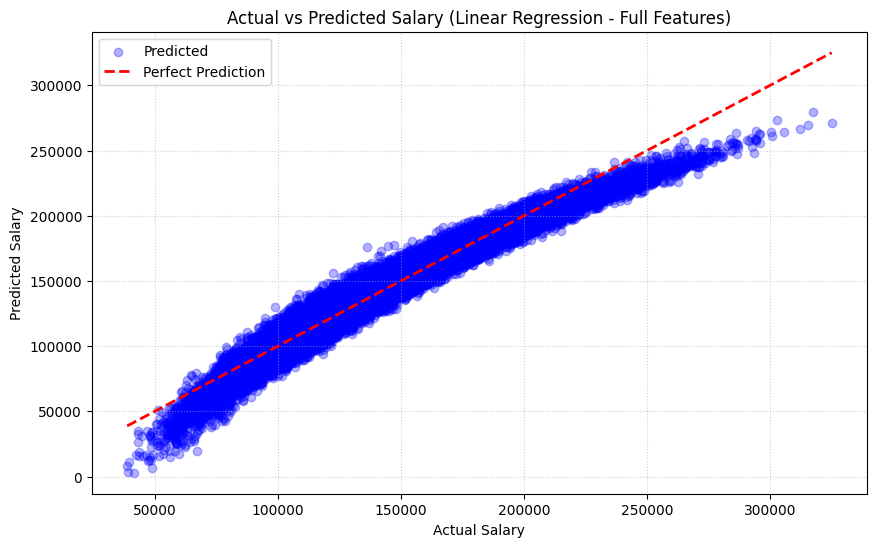

In [ ]:
import matplotlib.pyplot as plt

# Visualize Actual vs Predicted Salaries for Linear Regression (Full Dataset)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_full, y_test_pred_full, alpha=0.3, color='blue', label='Predicted')
plt.plot([y_test_full.min(), y_test_full.max()], [y_test_full.min(), y_test_full.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary (Linear Regression - Full Features)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

##Simple Linear Regression on Reduced Dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Defining features (X) and target (y) from the selected dataframe
X_sel = df_selected.drop('salary', axis=1)
y_sel = df_selected['salary']

# Splitting the data
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_sel, y_sel, test_size=0.2, random_state=42)

# Initialize and train the model
lr_model_sel = LinearRegression()
lr_model_sel.fit(X_train_sel, y_train_sel)

# Predictions for evaluation
y_train_pred = lr_model_sel.predict(X_train_sel)
y_test_pred = lr_model_sel.predict(X_test_sel)

# Calculate Metrics
def get_performance_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

mse_train, rmse_train, r2_train = get_performance_metrics(y_train_sel, y_train_pred)
mse_test, rmse_test, r2_test = get_performance_metrics(y_test_sel, y_test_pred)

# Display Results
print("--- Training Set Performance ---")
print(f"Accuracy (R2 Score): {r2_train:.4f}")
print(f"MSE: {mse_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")

print("\n--- Test Set Performance ---")
print(f"Accuracy (R2 Score): {r2_test:.4f}")
print(f"MSE: {mse_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")

--- Training Set Performance ---
Accuracy (R2 Score): 0.9184
MSE: 114411984.43
RMSE: 10696.35

--- Test Set Performance ---
Accuracy (R2 Score): 0.9174
MSE: 114747049.63
RMSE: 10712.00


### Comparison of Full vs. Reduced Feature Models
We will now compare the performance metrics of the Linear Regression model trained on all 37 features (`df_encoded`) versus the one trained on the selected 23 features (`df_selected`).

Performance Comparison (Test Set):


,Metric,Full Model (37 Features),Reduced Model (23 Features),Difference (%)
0,R2 Score,9.553766e-01,9.174401e-01,-3.970847
1,MSE,6.202043e+07,1.147470e+08,85.014916
2,RMSE,7.875305e+03,1.071200e+04,36.020188


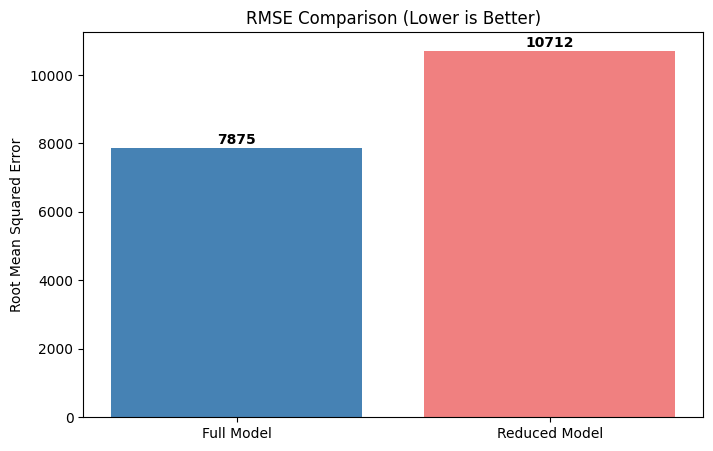

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a dictionary for the comparison
comparison_data = {
    'Metric': ['R2 Score', 'MSE', 'RMSE'],
    'Full Model (37 Features)': [r2_test_f, mse_test_f, rmse_test_f],
    'Reduced Model (23 Features)': [r2_test, mse_test, rmse_test]
}

# Create DataFrame
comparison_table = pd.DataFrame(comparison_data)

# Calculate percentage difference for clarity
comparison_table['Difference (%)'] = ((comparison_table['Reduced Model (23 Features)'] - comparison_table['Full Model (37 Features)']) / comparison_table['Full Model (37 Features)']) * 100

print("Performance Comparison (Test Set):")
display(comparison_table)

# Visualizing the difference in RMSE
plt.figure(figsize=(8, 5))
models = ['Full Model', 'Reduced Model']
rmse_values = [rmse_test_f, rmse_test]

plt.bar(models, rmse_values, color=['steelblue', 'lightcoral'])
plt.title('RMSE Comparison (Lower is Better)')
plt.ylabel('Root Mean Squared Error')
for i, v in enumerate(rmse_values):
    plt.text(i, v + 100, f"{v:.0f}", ha='center', fontweight='bold')
plt.show()

* The model trained on the full dataset actually performed better, achieving an R² score of 0.9554 compared to the 0.9174 we got with fewer features.
* This suggests that while those individual features had low linear correlation on their own, they likely provided useful collective information that helped the model refine its predictions.

## Train Decision Tree, KNN, Random forest and XGboost

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize Models
models_full = {
    'KNN': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results_list = []

# Loop through and train on the full training set (X_train_full)
for name, model in models_full.items():
    model.fit(X_train_full, y_train_full)
    preds = model.predict(X_test_full)

    mae = mean_absolute_error(y_test_full, preds)
    rmse = np.sqrt(mean_squared_error(y_test_full, preds))
    r2 = r2_score(y_test_full, preds)

    results_list.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

# Create a comparison table
full_model_comparison = pd.DataFrame(results_list)

print("Evaluation on Full Encoded Dataset (37 Features):")
display(full_model_comparison.sort_values(by='R2 Score', ascending=False))

Evaluation on Full Encoded Dataset (37 Features):


,Model,MAE,RMSE,R2 Score
3,XGBoost,4503.388368,5760.255476,0.976127
2,Random Forest,5542.889571,7173.500151,0.962975
1,Decision Tree,7925.373550,10366.493217,0.922680
0,KNN,15113.959296,19529.233890,0.725591


## Finetune hyperparameters of our best performer model XGboost using RandomizedSearch Cross validation.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize XGBRegressor
xgb_reg = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# Initialize RandomizedSearchCV
# Using 3-fold CV and 10 iterations to keep execution time reasonable
xgb_random = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the random search model
xgb_random.fit(X_train_full, y_train_full)

# Print best parameters and score
print(f"Best Parameters: {xgb_random.best_params_}")
print(f"Best CV R2 Score: {xgb_random.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV R2 Score: 0.9797


##Train Xgboost model on finetuned parameters.

In [ ]:
# Evaluate the tuned model on the test set
best_xgb = xgb_random.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_full)

mae_tuned = mean_absolute_error(y_test_full, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_full, y_pred_tuned))
r2_tuned = r2_score(y_test_full, y_pred_tuned)

print("--- Tuned XGBoost Performance ---")
print(f"MAE: {mae_tuned:.2f}")
print(f"RMSE: {rmse_tuned:.2f}")
print(f"R2 Score: {r2_tuned:.4f}")

--- Tuned XGBoost Performance ---
MAE: 4185.66
RMSE: 5264.28
R2 Score: 0.9801


##Visualize Important features for XGboost model.

<Figure size 1000x800 with 0 Axes>

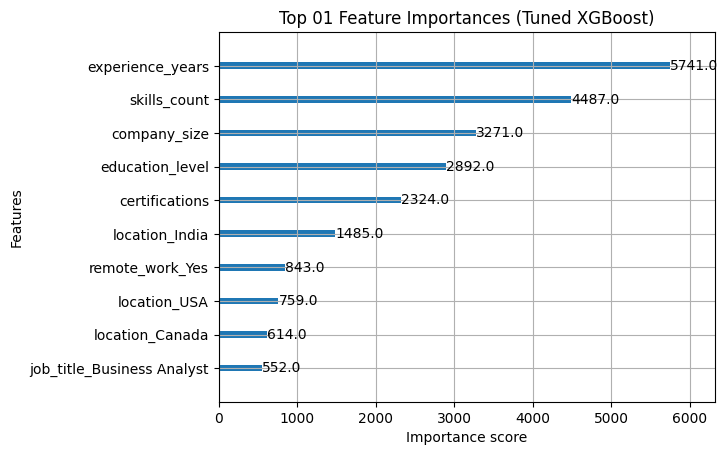

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Visualize feature importance for the tuned XGBoost model
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb, max_num_features=10, importance_type='weight')
plt.title('Top 01 Feature Importances (Tuned XGBoost)')
plt.show()

* This feature importance plot for Xgboost model reveals that experience_years is the most significant predictor of salary, followed by skills_count and company_size.

##Visualize Predicated Vs. Actual salary for Xgboost.

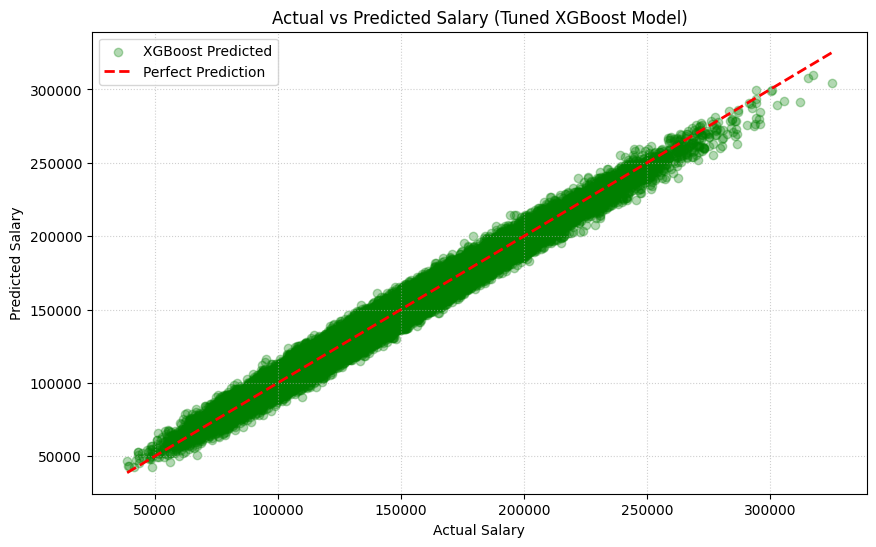

In [ ]:
import matplotlib.pyplot as plt

# Visualize Actual vs Predicted Salaries for the Tuned XGBoost Model
plt.figure(figsize=(10, 6))
plt.scatter(y_test_full, y_pred_tuned, alpha=0.3, color='green', label='XGBoost Predicted')
plt.plot([y_test_full.min(), y_test_full.max()], [y_test_full.min(), y_test_full.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary (Tuned XGBoost Model)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

* XGBoost is significantly more accurate than the Linear Regression model (which had an R² of 0.98). This confirms that there are non-linear interactions between features like location, job title, and experience that the tree-based models are capturing better.
* Random Forest is also performing better with R2 score of 0.96.
* Decision Tree (0.922) performed worse than the full Linear Regression, likely due to its tendency to overfit or its inability to capture the same global patterns as the ensembles.
* KNN (0.725) remains the weakest performer, confirming that distance-based metrics are not ideal for this specific mix of ordinal and one-hot encoded categorical data.

# Final Performance Comparision between All Models

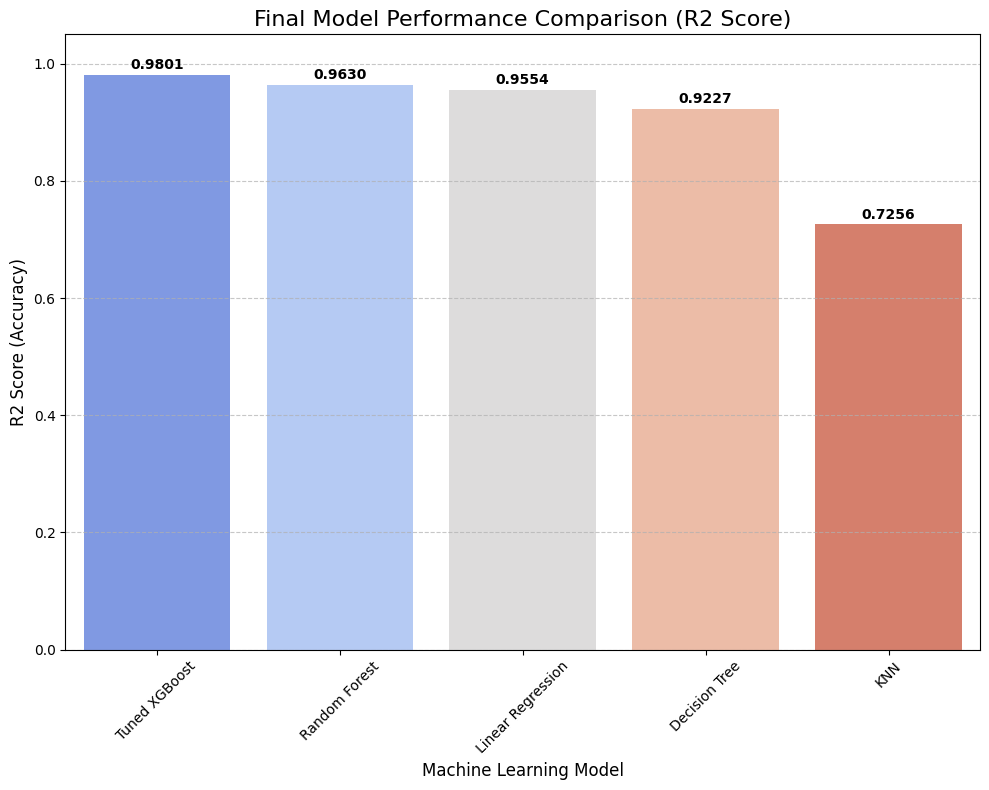

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consolidate results for final comparison
final_comparison = {
    'Model': ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Tuned XGBoost'],
    'R2 Score': [r2_test_f, 0.7256, 0.9227, 0.9630, r2_tuned]
}

comparison_df = pd.DataFrame(final_comparison).sort_values(by='R2 Score', ascending=False)

# Visualize the accuracy comparison (Vertical Orientation)
plt.figure(figsize=(10, 8))
sns.barplot(y='R2 Score', x='Model', data=comparison_df, palette='coolwarm', hue='Model', legend=False)

# Adding labels and titles
plt.title('Final Model Performance Comparison (R2 Score)', fontsize=16)
plt.ylabel('R2 Score (Accuracy)', fontsize=12)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Annotate bars with scores
for i, v in enumerate(comparison_df['R2 Score']):
    plt.text(i, v + 0.01, f"{v:.4f}", color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()